In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [53]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/loan_approval_dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [55]:
df.shape

(4269, 13)

In [56]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [57]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [58]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [59]:
print("Number of duplicated records: ",df.duplicated().sum())

Number of duplicated records:  0


In [60]:
#feature summary
numerical_features=df.select_dtypes(include=['int64','float64']).columns
categorical_features=df.select_dtypes(include=['object']).columns
print("Feature Summary")
print("Numerical features:")
for col in numerical_features:
    print("-",col)
print("Categorical features: ")
for col in categorical_features:
    print("-",col)

Feature Summary
Numerical features:
- loan_id
-  no_of_dependents
-  income_annum
-  loan_amount
-  loan_term
-  cibil_score
-  residential_assets_value
-  commercial_assets_value
-  luxury_assets_value
-  bank_asset_value
Categorical features: 
-  education
-  self_employed
-  loan_status


In [61]:
df.columns = df.columns.str.strip()
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])

In [62]:
df.columns = df.columns.str.strip()

# Only apply the mapping if 'loan_status' is still an object (string) dtype
if df['loan_status'].dtype == 'object':
    df['loan_status'] = df['loan_status'].str.strip().map({
    'Approved': 1,
    'Rejected': 0
    })

In [63]:
# Separate features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print("Features (X) and target (y) separated successfully")

Features (X) and target (y) separated successfully


In [64]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [65]:
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (3415, 12)
Testing set size: (854, 12)


In [66]:
#model building
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [67]:
#predictions on test data
y_pred=model.predict(x_test)

In [68]:
#evaluation metrics
confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[312  11]
 [  5 526]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

0.9812646370023419


In [69]:
# Training Accuracy
train_accuracy = model.score(x_train, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 100.00%
Testing Accuracy: 98.13%


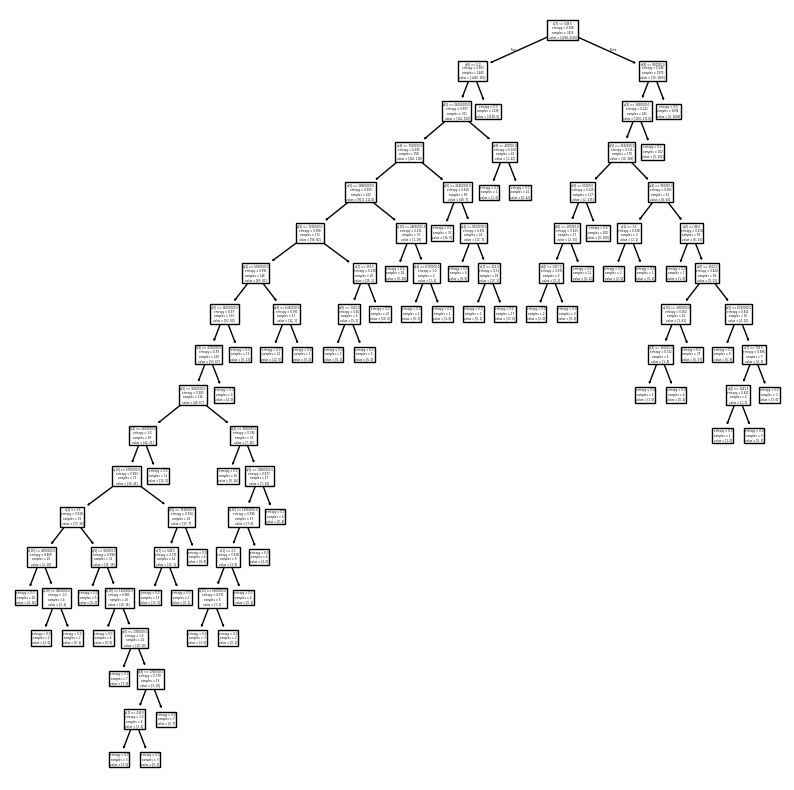

In [71]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(model)
plt.show()

In [72]:
#auc_roc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.9782640382944735)

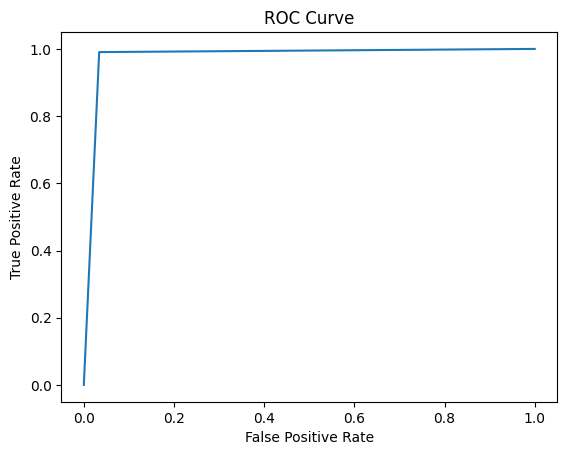

In [76]:
#roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()